In [1]:
import pandas as pd
import numpy as np

# data loading

In [2]:
df=pd.read_csv("hand_landmarks_data.csv")

In [3]:
df.head().T

,0,1,2,3,4
x1,262.669968,83.351778,187.756977,114.976696,188.795288
y1,257.304901,346.059113,260.235492,331.594238,141.727867
z1,-0.0,-0.0,-0.0,-0.0,-0.0
x2,257.417542,81.925037,195.460579,114.503494,188.520905
y2,247.109055,328.562347,241.506035,320.549957,127.947464
...,...,...,...,...,...
z20,-0.024577,-0.037336,-0.040469,-0.027863,-0.024087
x21,208.006393,152.431698,272.989952,155.990364,241.587769
y21,259.608673,343.015991,272.272231,329.548828,128.477188
z21,-0.026722,-0.036136,-0.038301,-0.027723,-0.023486


In [4]:
df['label'].unique()

array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
       'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
       'three', 'three2', 'two_up', 'two_up_inverted'], dtype=object)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

# Data Visualization

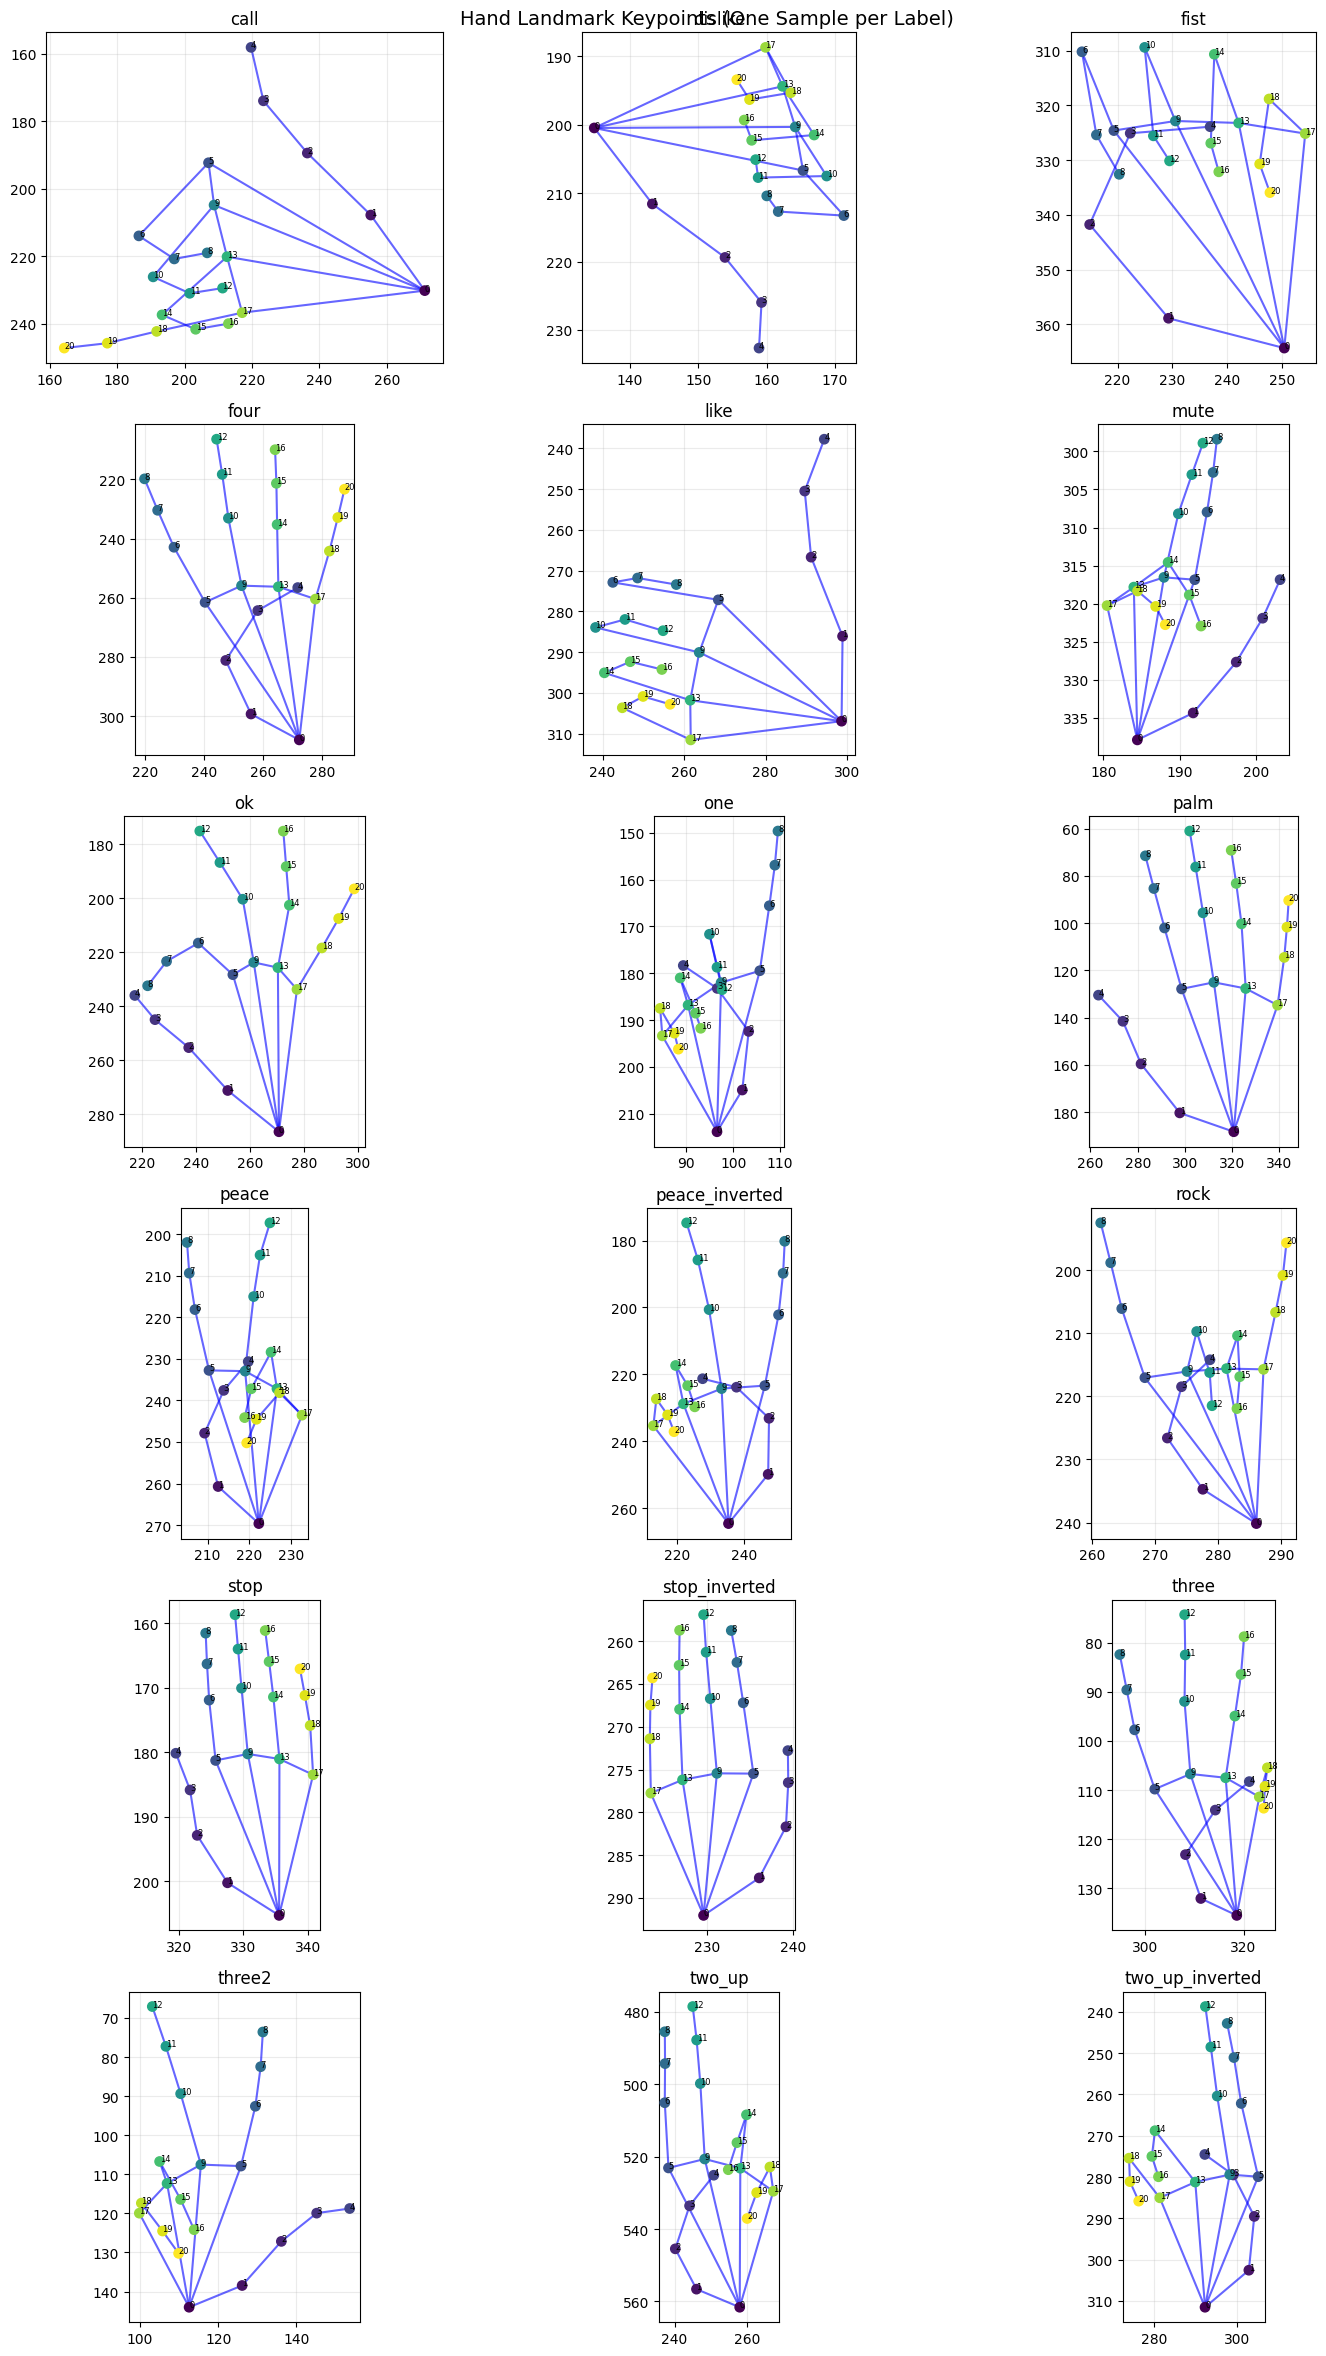

In [6]:
import matplotlib.pyplot as plt
import re
import math

# Detect x/y landmark columns (supports names like x0, x_0, y0, y_0)
def _sorted_landmark_cols(cols, axis_prefix):
    matched = [c for c in cols if re.match(rf"^{axis_prefix}_?\d+$", c, flags=re.IGNORECASE)]
    return sorted(matched, key=lambda c: int(re.findall(r"\d+", c)[0]))

x_cols = _sorted_landmark_cols(df.columns, "x")
y_cols = _sorted_landmark_cols(df.columns, "y")

# Fallback if columns are stored as repeating x,y,z triplets without x*/y* names
if not x_cols or not y_cols:
    feature_cols = [c for c in df.columns if c != "label"]
    if len(feature_cols) % 3 == 0:
        x_cols = feature_cols[0::3]
        y_cols = feature_cols[1::3]

if not x_cols or not y_cols:
    raise ValueError("Could not infer x/y landmark columns from the dataset.")

if "label" not in df.columns:
    raise ValueError("Column 'label' is required for one-sample-per-label visualization.")

# Pick exactly one sample per label (keeps the label column intact)
sample_df = df.groupby("label", as_index=False).sample(n=1, random_state=42).reset_index(drop=True)

n_labels = len(sample_df)
n_cols = min(3, n_labels)
n_rows = math.ceil(n_labels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    x = row[x_cols].astype(float).to_numpy()
    y = row[y_cols].astype(float).to_numpy()

    # Define hand landmark connections (MediaPipe hand structure)
    connections = [
        # Thumb
        (0, 1), (1, 2), (2, 3), (3, 4),
        # Index finger
        (0, 5), (5, 6), (6, 7), (7, 8),
        # Middle finger
        (0, 9), (9, 10), (10, 11), (11, 12),
        # Ring finger
        (0, 13), (13, 14), (14, 15), (15, 16),
        # Pinky
        (0, 17), (17, 18), (18, 19), (19, 20),
        # Palm connections
        (5, 9), (9, 13), (13, 17)
    ]
    
    # Draw connections as lines
    for start, end in connections:
        if start < len(x) and end < len(x):
            ax.plot([x[start], x[end]], [y[start], y[end]], 
                   'b-', linewidth=1.5, alpha=0.6)
    
    # Draw landmarks as scatter points on top
    ax.scatter(x, y, s=45, c=range(len(x)), cmap="viridis", zorder=3)

    # Label each keypoint index to make landmark positions easy to inspect
    for i, (xi, yi) in enumerate(zip(x, y)):
        ax.text(xi, yi, str(i), fontsize=6, zorder=4)

    ax.set_title(str(row["label"]))
    ax.set_aspect("equal")
    ax.invert_yaxis()  # image-style orientation
    ax.grid(alpha=0.25)

# Hide any unused axes
for j in range(n_labels, len(axes)):
    axes[j].axis("off")

plt.suptitle("Hand Landmark Keypoints (One Sample per Label)", fontsize=14)
plt.tight_layout()
plt.show()

# Landmark Normalization

Normalize hand landmarks to handle different scales and positions:
- Recenter all (x,y) coordinates to make wrist (landmark 1) the origin
- Scale by dividing by the distance to mid-finger tip (landmark 12)
- z coordinates are already normalized, so no processing needed

In [7]:
# Normalize hand landmarks to make scale and position invariant
# MediaPipe hand landmarks: 21 points (1-21), where 1 is wrist and 12 is mid-finger tip

# Create a copy for normalization
df_normalized = df.copy()

# Identify all coordinate columns
x_cols = [f'x{i}' for i in range(1, 22)]
y_cols = [f'y{i}' for i in range(1, 22)]
z_cols = [f'z{i}' for i in range(1, 22)]

# Normalize each row
for idx in df_normalized.index:
    # Extract all x and y coordinates for this sample
    x_coords = df_normalized.loc[idx, x_cols].values.astype(float)
    y_coords = df_normalized.loc[idx, y_cols].values.astype(float)
    
    # Step 1: Recenter - subtract wrist position (landmark 1) from all landmarks
    wrist_x = x_coords[0]  # x1 is at index 0
    wrist_y = y_coords[0]  # y1 is at index 0
    
    x_coords_recentered = x_coords - wrist_x
    y_coords_recentered = y_coords - wrist_y
    
    # Step 2: Scale - divide by distance from origin to mid-finger tip (landmark 12)
    # After recentering, mid-finger tip is at index 11 (landmark 12)
    mid_finger_x = x_coords_recentered[11]  # x12 is at index 11
    mid_finger_y = y_coords_recentered[11]  # y12 is at index 11
    
    # Calculate distance (avoid division by zero)
    scale_factor = np.sqrt(mid_finger_x**2 + mid_finger_y**2)
    if scale_factor < 1e-6:  # Handle edge case of very small scale
        scale_factor = 1.0
    
    # Apply scaling to recentered coordinates
    x_coords_normalized = x_coords_recentered / scale_factor
    y_coords_normalized = y_coords_recentered / scale_factor
    
    # Update dataframe with normalized values
    df_normalized.loc[idx, x_cols] = x_coords_normalized
    df_normalized.loc[idx, y_cols] = y_coords_normalized
    # z coordinates remain unchanged as they're already normalized

# Replace original dataframe with normalized version
df = df_normalized

print("Landmark normalization complete!")
print(f"All hand landmarks recentered to wrist and scaled by mid-finger tip distance.")
print(f"Processed {len(df)} samples.")

Landmark normalization complete!
All hand landmarks recentered to wrist and scaled by mid-finger tip distance.
Processed 25675 samples.


In [8]:
# Verify normalization - show that wrist is at origin and mid-finger tip distance is ~1
sample_idx = 0
x_cols_check = [f'x{i}' for i in range(1, 22)]
y_cols_check = [f'y{i}' for i in range(1, 22)]

sample_x = df.iloc[sample_idx][x_cols_check].values
sample_y = df.iloc[sample_idx][y_cols_check].values

print("After normalization verification:")
print(f"Wrist position (landmark 1): ({sample_x[0]:.6f}, {sample_y[0]:.6f}) - should be ~(0, 0)")
print(f"Mid-finger tip (landmark 12): ({sample_x[11]:.6f}, {sample_y[11]:.6f})")
print(f"Distance to mid-finger tip: {np.sqrt(sample_x[11]**2 + sample_y[11]**2):.6f} - should be ~1.0")

After normalization verification:
Wrist position (landmark 1): (0.000000, 0.000000) - should be ~(0, 0)
Mid-finger tip (landmark 12): (-0.995550, 0.094234)
Distance to mid-finger tip: 1.000000 - should be ~1.0


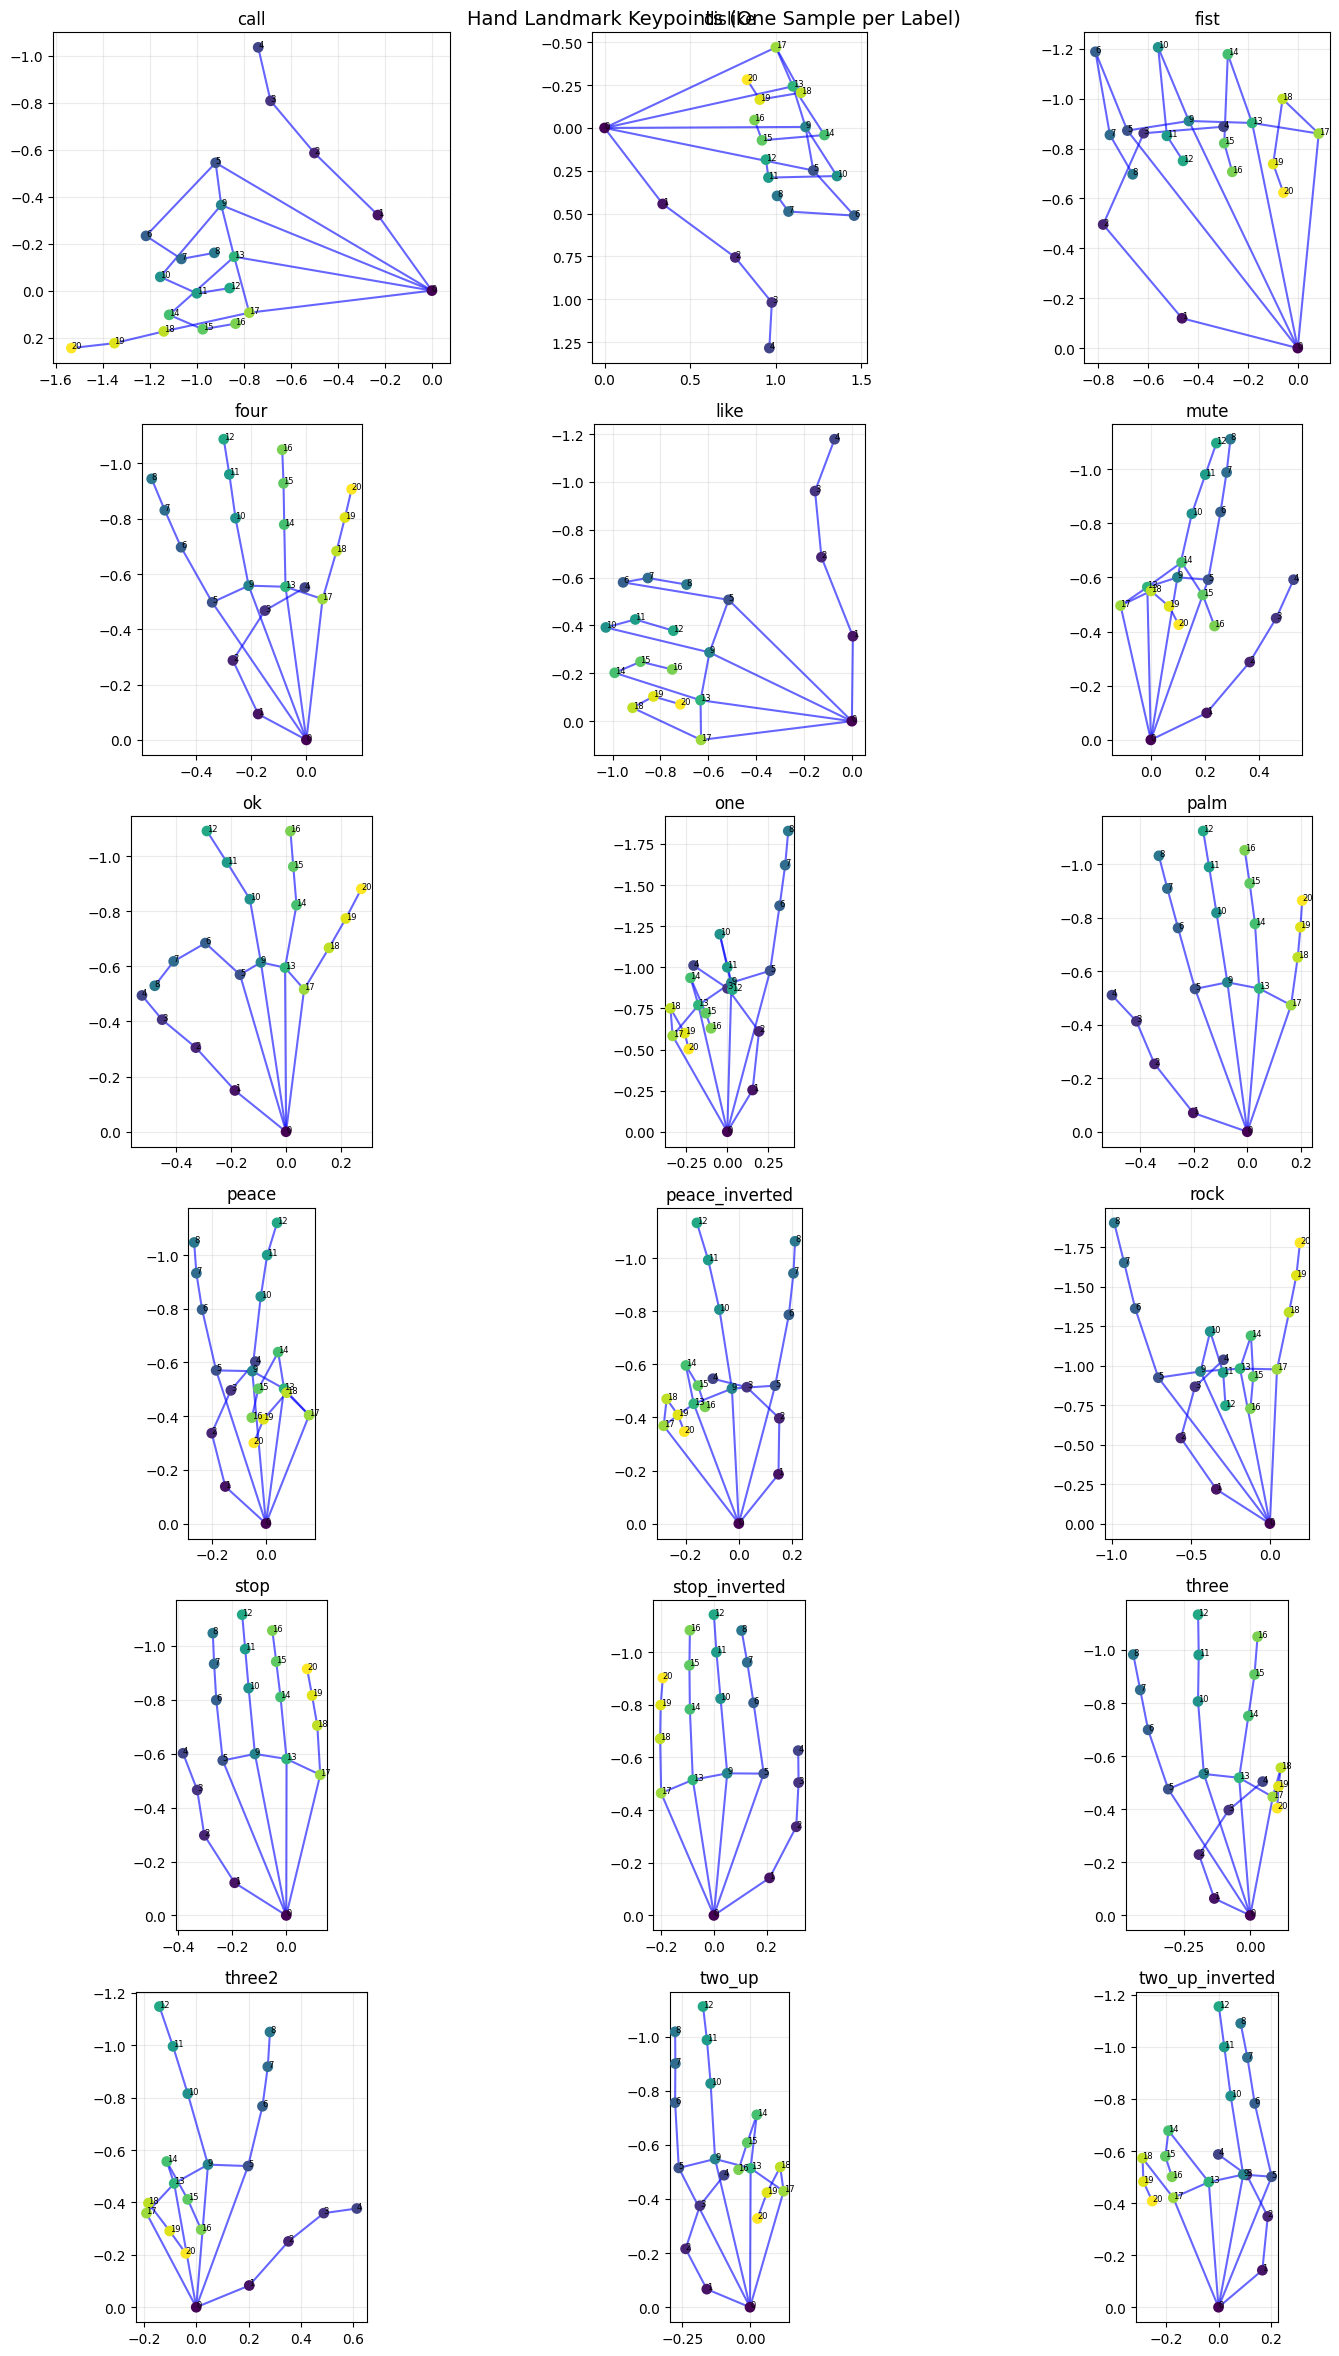

In [9]:
x_cols = _sorted_landmark_cols(df.columns, "x")
y_cols = _sorted_landmark_cols(df.columns, "y")

# Fallback if columns are stored as repeating x,y,z triplets without x*/y* names
if not x_cols or not y_cols:
    feature_cols = [c for c in df.columns if c != "label"]
    if len(feature_cols) % 3 == 0:
        x_cols = feature_cols[0::3]
        y_cols = feature_cols[1::3]

if not x_cols or not y_cols:
    raise ValueError("Could not infer x/y landmark columns from the dataset.")

if "label" not in df.columns:
    raise ValueError("Column 'label' is required for one-sample-per-label visualization.")

# Pick exactly one sample per label (keeps the label column intact)
sample_df = df.groupby("label", as_index=False).sample(n=1, random_state=42).reset_index(drop=True)

n_labels = len(sample_df)
n_cols = min(3, n_labels)
n_rows = math.ceil(n_labels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    x = row[x_cols].astype(float).to_numpy()
    y = row[y_cols].astype(float).to_numpy()

    # Define hand landmark connections (MediaPipe hand structure)
    connections = [
        # Thumb
        (0, 1), (1, 2), (2, 3), (3, 4),
        # Index finger
        (0, 5), (5, 6), (6, 7), (7, 8),
        # Middle finger
        (0, 9), (9, 10), (10, 11), (11, 12),
        # Ring finger
        (0, 13), (13, 14), (14, 15), (15, 16),
        # Pinky
        (0, 17), (17, 18), (18, 19), (19, 20),
        # Palm connections
        (5, 9), (9, 13), (13, 17)
    ]
    
    # Draw connections as lines
    for start, end in connections:
        if start < len(x) and end < len(x):
            ax.plot([x[start], x[end]], [y[start], y[end]], 
                   'b-', linewidth=1.5, alpha=0.6)
    
    # Draw landmarks as scatter points on top
    ax.scatter(x, y, s=45, c=range(len(x)), cmap="viridis", zorder=3)

    # Label each keypoint index to make landmark positions easy to inspect
    for i, (xi, yi) in enumerate(zip(x, y)):
        ax.text(xi, yi, str(i), fontsize=6, zorder=4)

    ax.set_title(str(row["label"]))
    ax.set_aspect("equal")
    ax.invert_yaxis()  # image-style orientation
    ax.grid(alpha=0.25)

# Hide any unused axes
for j in range(n_labels, len(axes)):
    axes[j].axis("off")

plt.suptitle("Hand Landmark Keypoints (One Sample per Label)", fontsize=14)
plt.tight_layout()
plt.show()

#  Data Preprocessing:


In [10]:
# Data preprocessing for model training
# 1) clean data, 2) handle missing values, 3) train/test split, 4) normalize features

RANDOM_STATE = 42
TEST_SIZE = 0.2
LABEL_COL = "label"


# Keep a working copy
proc_df = df.copy()

# Separate feature columns from target
feature_cols = [c for c in proc_df.columns if c != LABEL_COL]

# Convert all features to numeric and coerce invalid values to NaN
proc_df[feature_cols] = proc_df[feature_cols].apply(pd.to_numeric, errors="coerce")

# Basic cleaning
before_rows = len(proc_df)
proc_df = proc_df.drop_duplicates().reset_index(drop=True)
after_rows = len(proc_df)

# Missing value handling: fill feature NaNs with feature-wise median
missing_before = proc_df[feature_cols].isna().sum().sum()
feature_medians = proc_df[feature_cols].mean()
proc_df[feature_cols] = proc_df[feature_cols].fillna(feature_medians)
missing_after = proc_df[feature_cols].isna().sum().sum()

# If any label is missing, drop those rows
proc_df = proc_df.dropna(subset=[LABEL_COL]).reset_index(drop=True)

# Build X/y
X = proc_df[feature_cols].copy()
y = proc_df[LABEL_COL].copy()

# Optional numeric encoding for classification models
label_to_id = {label: i for i, label in enumerate(sorted(y.unique()))}
y_encoded = y.map(label_to_id)

# Stratified train/test split without sklearn dependency
rng = np.random.default_rng(RANDOM_STATE)
train_idx = []
test_idx = []

for label, group in proc_df.groupby(LABEL_COL):
    indices = group.index.to_numpy().copy()
    rng.shuffle(indices)

    n_test = max(1, int(round(len(indices) * TEST_SIZE)))
    n_test = min(n_test, len(indices) - 1) if len(indices) > 1 else 1

    test_idx.extend(indices[:n_test])
    train_idx.extend(indices[n_test:])

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train = X.loc[train_idx].reset_index(drop=True)
X_test = X.loc[test_idx].reset_index(drop=True)
y_train = y.loc[train_idx].reset_index(drop=True)
y_test = y.loc[test_idx].reset_index(drop=True)
y_train_encoded = y_encoded.loc[train_idx].reset_index(drop=True)
y_test_encoded = y_encoded.loc[test_idx].reset_index(drop=True)

# Normalize with train-set statistics only (prevents data leakage)
train_mean = X_train.mean()
train_std = X_train.std().replace(0, 1.0)

X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("Preprocessing complete")
print(f"Rows before/after duplicate removal: {before_rows}/{after_rows}")
print(f"Missing feature values before/after fill: {int(missing_before)}/{int(missing_after)}")
print(f"Train shape: {X_train_norm.shape}, Test shape: {X_test_norm.shape}")
print(f"Number of classes: {len(label_to_id)}")
print("Label mapping:", label_to_id)

# Final training-ready objects:
# X_train_norm, X_test_norm, y_train_encoded, y_test_encoded


Preprocessing complete
Rows before/after duplicate removal: 25675/25675
Missing feature values before/after fill: 0/0
Train shape: (20541, 63), Test shape: (5134, 63)
Number of classes: 18
Label mapping: {'call': 0, 'dislike': 1, 'fist': 2, 'four': 3, 'like': 4, 'mute': 5, 'ok': 6, 'one': 7, 'palm': 8, 'peace': 9, 'peace_inverted': 10, 'rock': 11, 'stop': 12, 'stop_inverted': 13, 'three': 14, 'three2': 15, 'two_up': 16, 'two_up_inverted': 17}


# Model Training

In [11]:
from time import perf_counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV

# Ensure preprocessing cell has been executed
required_vars = ["X_train_norm", "X_test_norm", "y_train", "y_test"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Run the preprocessing cell first. Missing variables: {missing_vars}"
    )

# Define base models and parameter distributions for randomized search
model_configs = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", None]
        }
    },
    "SVM (RBF)": {
        "model": SVC(kernel="rbf", random_state=42),
        "params": {
            "C": [0.1, 0.5, 1, 2],
            "gamma": ["scale", "auto", 0.001, 0.01]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11, 15],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan", "minkowski"],
            "p": [1, 2]
        }
    }
}

# Run Halving Random Search for each model
# How it works: starts with 20 candidates on a small data subset,
# each round keeps the top 1/3 (factor=3) and trains on 3x more data,
# so only the best ~2 candidates ever train on the full dataset.
print("Running Halving Random Search for hyperparameter tuning...")
print("=" * 60)

results = []
trained_models = {}
best_params_dict = {}

for model_name, config in model_configs.items():
    print(f"\n{model_name}:")
    print("-" * 40)
    
    t0 = perf_counter()
    
    random_search = HalvingRandomSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_candidates=20,          # start with 20 candidates in round 1
        factor=3,                 # keep top 1/3 each round, use 3x more data each round
        cv=2,                     # 2-fold CV (fast, enough for elimination rounds)
        scoring="accuracy",
        aggressive_elimination=True,  # eliminate poor candidates even if data is limited
        n_jobs=-1,
        random_state=42,
    )
    
    random_search.fit(X_train_norm, y_train)
    search_time = perf_counter() - t0
    
    # Get best model
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_params_dict[model_name] = best_params
    
    print(f"Best parameters: {best_params}")
    print(f"Best CV score: {random_search.best_score_:.4f}")
    print(f"Search time: {search_time:.2f}s")
    
    # Evaluate on test set
    y_pred = best_model.predict(X_test_norm)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    
    results.append(
        {
            "Model": model_name,
            "Accuracy": acc,
            "Macro F1": f1,
            "CV Score": random_search.best_score_,
            "Search Time (s)": search_time,
        }
    )
    trained_models[model_name] = best_model

print("\n" + "=" * 60)
print("\nModel comparison (with optimized hyperparameters):")
results_df = pd.DataFrame(results).sort_values(by=["Accuracy", "Macro F1"], ascending=False)
display(results_df.reset_index(drop=True))

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
y_best_pred = best_model.predict(X_test_norm)

print(f"\nBest model: {best_model_name}")
print(f"Best hyperparameters: {best_params_dict[best_model_name]}")
print("\nClassification report (best model):")
print(classification_report(y_test, y_best_pred))


Running Halving Random Search for hyperparameter tuning...

Random Forest:
----------------------------------------
Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV score: 0.9682
Search time: 222.62s

SVM (RBF):
----------------------------------------


c:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'gamma': 'scale', 'C': 2}
Best CV score: 0.9455
Search time: 59.71s

KNN:
----------------------------------------
Best parameters: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'euclidean'}
Best CV score: 0.9298
Search time: 6.96s


Model comparison (with optimized hyperparameters):


,Model,Accuracy,Macro F1,CV Score,Search Time (s)
0,Random Forest,0.981106,0.980885,0.968220,222.619981
1,SVM (RBF),0.972341,0.972102,0.945470,59.710235
2,KNN,0.947020,0.947577,0.929752,6.956527



Best model: Random Forest
Best hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

Classification report (best model):
                 precision    recall  f1-score   support

           call       1.00      0.98      0.99       301
        dislike       1.00      1.00      1.00       259
           fist       1.00      0.99      0.99       189
           four       0.98      0.98      0.98       327
           like       0.99      1.00      0.99       287
           mute       0.96      0.97      0.96       217
             ok       1.00      0.99      1.00       318
            one       0.97      0.98      0.97       253
           palm       0.98      0.98      0.98       330
          peace       0.97      0.97      0.97       288
 peace_inverted       0.96      0.98      0.97       299
           rock       0.99      1.00      1.00       292
           stop       0.95      0.97      0.96       296
  sto

## Conclusion

Three models were trained to classify hand gestures using MediaPipe landmarks.

Random Forest achieved the highest accuracy and best F1-score,
so it was selected as the final model.

Normalization helped improve consistency across different hand positions and scales.